# Notebook 3 - Modeling binding affinity to protein receptors

By Vincent Blay, November 2021

This notebook was developed using **RPReactor 3.8** kernel on [jprime.lbl.gov](https://gpu2.ese.lbl.gov/).

In this notebook, we demonstrate the use of MACAW embeddings to model binding affinity to a protein receptor of pharmacological interest. MACAW embeddings are then applied to identify promising candidate molecules in a custom virtual library.

In [74]:
import os
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import r2_score

#Needed to show molecules
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole 

import sys
sys.path.append('../')

import macaw
print(macaw.__version__)
from macaw import *

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans']
matplotlib.rcParams['figure.dpi'] = 96
matplotlib.rcParams['savefig.dpi'] = 600

%run "./plotting.py"

1.0.1


In [58]:
%config InlineBackend.figure_format = 'retina'

## 1. Binding to histamine H1 receptor

### 1.1 Data preparation

In [59]:
dataDir = '/mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/'
modelBuildingDataDir = os.path.join(dataDir, 'modelBuildingData/')
resultsDir = os.path.join(dataDir, 'Results/')

In [60]:
allVirusData_chEMBL_wMACAW = pd.read_csv(modelBuildingDataDir + 'allVirusData_chEMBL_uM_wMACAW.csv')

In [61]:
allVirusData_chEMBL_wMACAW.columns

Index(['Unnamed: 0', 'molecule_chembl_id', 'smiles', 'molecular_formula',
       'inchi_key', 'inchi', 'molecular_weight', 'type', 'standard_value',
       'standard_units', 'standard_relation', 'standard_type', 'pchembl_value',
       'AlogP', 'polar_surface_area', 'hba', 'hbd', 'rotatable_bonds',
       'qed_weighted', 'heavy_atoms', 'aromatic_rings', 'ro5_violations',
       'Target ChEMBL ID', 'Target Name', 'Target Organism', 'Virus',
       'value_uM', 'pPotency', 'pPotencyMid', 'invalidSmiles', 'macaw_0',
       'macaw_1', 'macaw_2', 'macaw_3', 'macaw_4', 'macaw_5', 'macaw_6',
       'macaw_7', 'macaw_8', 'macaw_9', 'macaw_10', 'macaw_11', 'macaw_12',
       'macaw_13', 'macaw_14'],
      dtype='object')

### Filter columns

In [62]:
allVirusData_chEMBL_wMACAW = allVirusData_chEMBL_wMACAW.filter(
    items=["molecule_chembl_id", "smiles", "value_uM", "pPotency", "Target Organism"]
)
allVirusData_chEMBL_wMACAW

,molecule_chembl_id,smiles,value_uM,pPotency,Target Organism
0,CHEMBL2016757,N#C[C@@]1(c2ccc3c(N)ncnn23)O[C@H](CO)[C@@H](O)...,2.1200,5.673664,Henipavirus nipahense
1,CHEMBL5205032,CCC(CC)OC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@](...,0.0320,7.494850,Henipavirus nipahense
2,CHEMBL4065616,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,0.0290,7.537602,Henipavirus nipahense
3,CHEMBL4065616,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,0.0290,7.537602,Henipavirus nipahense
4,CHEMBL4065616,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,0.0290,7.537602,Henipavirus nipahense
...,...,...,...,...,...
1363,CHEMBL5590446,CC1(C)[C@H]2CC[C@](C)(C2)[C@H]1OC(=O)CCCN1CCCCC1,4.6000,5.337242,Marburgvirus
1364,CHEMBL5584026,CN1CCN(CC(=O)O[C@H]2C(C)(C)[C@H]3CC[C@]2(C)C3)CC1,25.0000,4.602060,Marburgvirus
1365,CHEMBL1631748,O=c1c(/C=N/Cc2ccco2)c(CSc2ccc(Cl)cc2)[nH]n1-c1...,0.0013,8.886057,Homo sapiens
1366,CHEMBL1630982,O=C(NCc1ccc2c(c1)OCO2)C(Cc1ccccc1)NS(=O)(=O)c1...,0.0016,8.795880,Homo sapiens


### Add some randomization

In [63]:
allVirusData_chEMBL_wMACAW = allVirusData_chEMBL_wMACAW.sample(frac=1, random_state=42).reset_index(drop=True)

### Rename columns

In [64]:
allVirusData_chEMBL_wMACAW = allVirusData_chEMBL_wMACAW.rename(columns={
    "molecule_chembl_id": "compound_id",
    "smiles": "Smiles",
})

### Add `ID` column to left

In [65]:
allVirusData_chEMBL_wMACAW.insert(0, 'ID', range(1, len(allVirusData_chEMBL_wMACAW) + 1))
allVirusData_chEMBL_wMACAW.head()

,ID,compound_id,Smiles,value_uM,pPotency,Target Organism
0,1,CHEMBL5402943,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(Cc1ccccc1)c1ccccc1,1.05000,5.978811,Ebolavirus
1,2,CHEMBL4871246,Cc1cc2ncc(-c3ccc(OC(C)(C)C)cc3)n2cc1-c1ccc(OC(...,0.00068,9.167491,Mammarenavirus lassaense
2,3,CHEMBL809,CN[C@H]1CC[C@@H](c2ccc(Cl)c(Cl)c2)c2ccccc21,3.73000,5.428291,Ebolavirus
3,4,CHEMBL5593065,CN(C)C1CCN(C(=O)c2cn(Cc3ccc(F)cc3)c3ccccc23)CC1,2.54000,5.595166,Ebolavirus
4,5,CHEMBL3187777,CCN1CCN(Cc2nc3ccc(C#N)cc3c(=O)n2-c2ccccc2)CC1,1.10000,5.958607,Venezuelan equine encephalitis virus


### Add another filer to keep only these four columns: `ID`, `compound_id`,	`Smiles`, `pPotency`

In [66]:
allVirusData_chEMBL_wMACAW = allVirusData_chEMBL_wMACAW.filter(
    items=["ID", "compound_id", "Smiles", "pPotency"]
)
allVirusData_chEMBL_wMACAW.head()

,ID,compound_id,Smiles,pPotency
0,1,CHEMBL5402943,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(Cc1ccccc1)c1ccccc1,5.978811
1,2,CHEMBL4871246,Cc1cc2ncc(-c3ccc(OC(C)(C)C)cc3)n2cc1-c1ccc(OC(...,9.167491
2,3,CHEMBL809,CN[C@H]1CC[C@@H](c2ccc(Cl)c(Cl)c2)c2ccccc21,5.428291
3,4,CHEMBL5593065,CN(C)C1CCN(C(=O)c2cn(Cc3ccc(F)cc3)c3ccccc23)CC1,5.595166
4,5,CHEMBL3187777,CCN1CCN(Cc2nc3ccc(C#N)cc3c(=O)n2-c2ccccc2)CC1,5.958607


### Remove NaN values in `pPotency` before cross-validation

In [67]:
# Drop rows where pPotency is NaN
allVirusData_chEMBL_wMACAW = allVirusData_chEMBL_wMACAW.dropna(subset=['pPotency'])

# Print shapes
print("Original shape:", allVirusData_chEMBL_wMACAW.shape)
print("Shape after dropping rows with NaN in 'pPotency':", allVirusData_chEMBL_wMACAW.shape)

Original shape: (1180, 4)
Shape after dropping rows with NaN in 'pPotency': (1180, 4)


### Remove duplicate compounds

In [68]:
# df = allVirusData_chEMBL_wMACAW
Y = allVirusData_chEMBL_wMACAW.pPotency
smiles = allVirusData_chEMBL_wMACAW.Smiles

In [69]:
print(len(smiles))

1180


### Normalize the potency data
$$
\begin{align}
\text{value (M)} &= \text{value}_{\mu M} \times 10^{-6} \\
p\text{Potency} &= -\log_{10}(\text{value (M)}) \\
&= 6 - \log_{10}(\text{value}_{\mu M})
\end{align}
$$

so, $$ pK_i = p\text{Potency} = 6 - \log_{10}(\text{value}_{\mu M}) $$

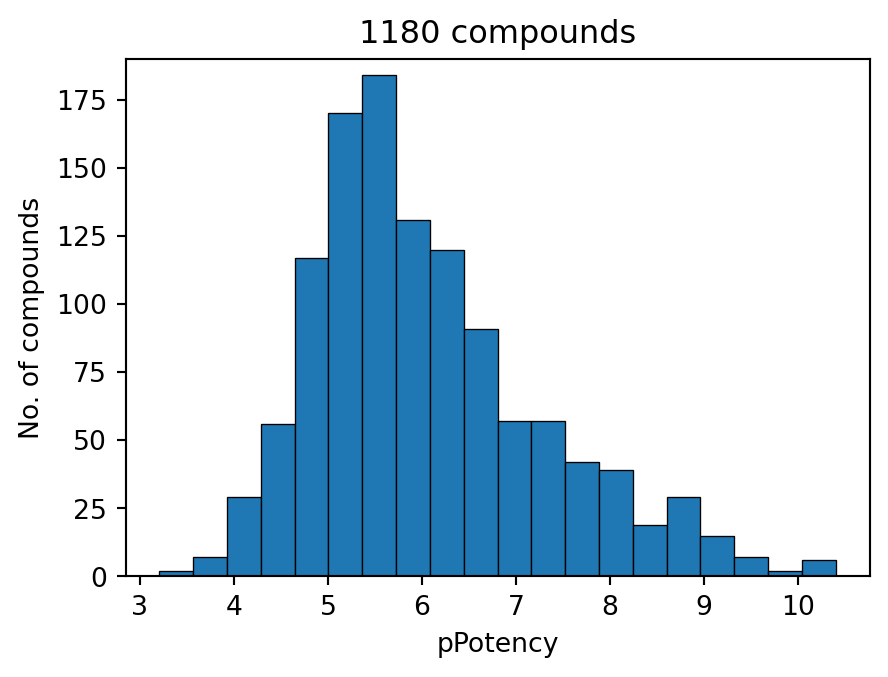

In [75]:
plot_histogram(Y, xlabel="pPotency")

Define the partitions for cross-validation.

In [76]:
num_of_partitions = 10
kf = KFold(n_splits=num_of_partitions, shuffle=True, random_state=42)

Define hyperparameters for SVR:

In [77]:
param_grid = {
    'C': [1, 5, 7, 10, 30, 50, 100, 300, 500], 
    'epsilon': [0.1, 0.3, 1, 3, 5, 10, 20],
    'kernel': ['rbf']
}

Define MACAW embedding:

In [78]:
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=15, 
    n_landmarks=200, 
    random_state=39
)


After cleaning NaN values, reset the indices

In [79]:
valid_mask = Y.notna()
smiles = smiles[valid_mask].reset_index(drop=True)  
Y = Y[valid_mask].reset_index(drop=True)            

print(f"Cleaned data has: {len(smiles)} samples")
print(f"Y index: {Y.index[:10].tolist()}")  

Cleaned data has: 1180 samples
Y index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [80]:
%%time

Y_cv_pred = []
Y_obs = []

i = 1
for train_index, val_index in kf.split(smiles):
    print(f"Partition {i}/{num_of_partitions}")
    i+=1
    smi_train , smi_val = smiles.iloc[train_index], smiles.iloc[val_index]
    y_train , y_val = Y[train_index], Y[val_index]
    
    # Compute MACAW embeddings
    mcw.fit(smi_train, y_train)
    
    X_train = mcw.transform(smi_train)
    X_val = mcw.transform(smi_val)
    
    # Train the SVR model
    # Optimize hyperparameters
    grid = GridSearchCV(SVR(), param_grid, cv=5, refit=True)
    grid.fit(X_train, y_train)
#     print(grid.best_params_)
    
    # Test set predictions
    y_cv_pred = grid.predict(X_val)
    
    # Save corresponding validation instances
    Y_cv_pred.extend(y_cv_pred)
    Y_obs.extend(y_val)

Partition 1/10


[12:55:05] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:05] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:05] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:05] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:05] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:05] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:05] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:05] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:05] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:05] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:05] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:05] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:05] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:05] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:05] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:05] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:05] DEPRECATION W

Partition 2/10


[12:55:11] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:11] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:11] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:11] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:11] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:11] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:11] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:11] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:11] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:11] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:11] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:11] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:11] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:11] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:11] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:11] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:11] DEPRECATION W

Partition 3/10


...

Partition 9/10


[12:55:53] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:53] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:53] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:53] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:53] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:53] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:53] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:53] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:53] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:53] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:53] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:53] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:53] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:53] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:53] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:53] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:53] DEPRECATION W

Partition 10/10


[12:55:59] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:59] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:59] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:59] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:59] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:59] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:59] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:59] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:59] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:59] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:59] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:59] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:59] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:59] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:59] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:59] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:59] DEPRECATION W

CPU times: user 59.9 s, sys: 39.7 ms, total: 60 s
Wall time: 59.9 s


Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/virus/allVirus_SVR.svg
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/virus/allVirus_SVR.png


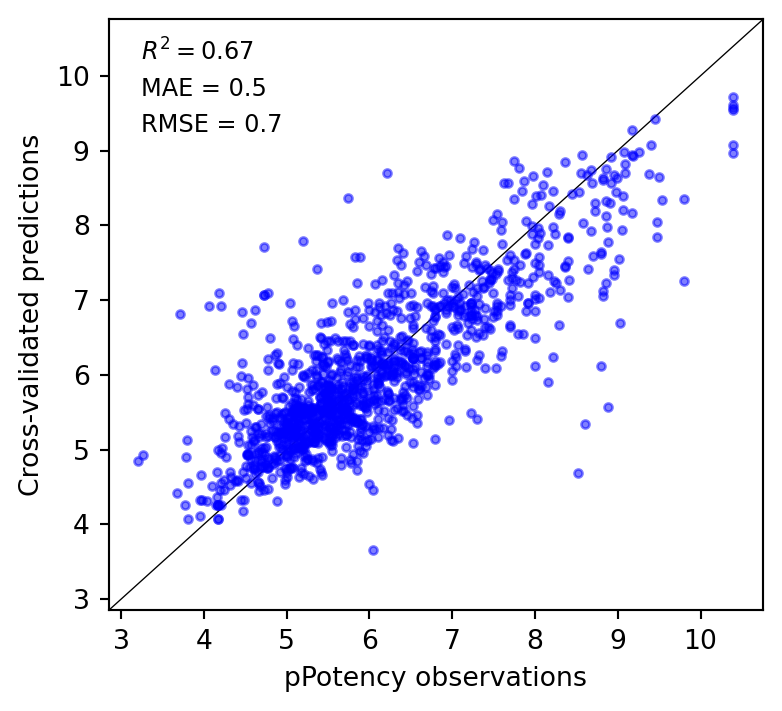

In [81]:
# Parity plot
parity_plot(x=Y_obs,
            y=Y_cv_pred, 
            xlabel="pPotency observations", 
            ylabel="Cross-validated predictions",
            savetitle=resultsDir + 'virus/allVirus_SVR.svg',
            save_formats=['svg', 'png'])  # Specify both formats

Generate a model trained on the whole data set, to be used for prediction tasks

In [82]:
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=15, 
    n_landmarks=200, 
    random_state=39
)
mcw.fit(smiles, Y)

[12:59:23] DEPRECATION WARNING: please use AtomPairGenerator
[12:59:23] DEPRECATION WARNING: please use AtomPairGenerator
[12:59:23] DEPRECATION WARNING: please use AtomPairGenerator
[12:59:23] DEPRECATION WARNING: please use AtomPairGenerator
[12:59:23] DEPRECATION WARNING: please use AtomPairGenerator
[12:59:23] DEPRECATION WARNING: please use AtomPairGenerator
[12:59:23] DEPRECATION WARNING: please use AtomPairGenerator
[12:59:23] DEPRECATION WARNING: please use AtomPairGenerator
[12:59:23] DEPRECATION WARNING: please use AtomPairGenerator
[12:59:23] DEPRECATION WARNING: please use AtomPairGenerator
[12:59:23] DEPRECATION WARNING: please use AtomPairGenerator
[12:59:23] DEPRECATION WARNING: please use AtomPairGenerator
[12:59:23] DEPRECATION WARNING: please use AtomPairGenerator
[12:59:23] DEPRECATION WARNING: please use AtomPairGenerator
[12:59:23] DEPRECATION WARNING: please use AtomPairGenerator
[12:59:23] DEPRECATION WARNING: please use AtomPairGenerator
[12:59:23] DEPRECATION W

In [83]:
X_all = mcw.transform(smiles)
X_all.shape

[13:03:43] DEPRECATION WARNING: please use AtomPairGenerator
[13:03:43] DEPRECATION WARNING: please use AtomPairGenerator
[13:03:43] DEPRECATION WARNING: please use AtomPairGenerator
[13:03:43] DEPRECATION WARNING: please use AtomPairGenerator
[13:03:43] DEPRECATION WARNING: please use AtomPairGenerator
[13:03:43] DEPRECATION WARNING: please use AtomPairGenerator
[13:03:43] DEPRECATION WARNING: please use AtomPairGenerator
[13:03:43] DEPRECATION WARNING: please use AtomPairGenerator
[13:03:43] DEPRECATION WARNING: please use AtomPairGenerator
[13:03:43] DEPRECATION WARNING: please use AtomPairGenerator
[13:03:43] DEPRECATION WARNING: please use AtomPairGenerator
[13:03:43] DEPRECATION WARNING: please use AtomPairGenerator
[13:03:43] DEPRECATION WARNING: please use AtomPairGenerator
[13:03:43] DEPRECATION WARNING: please use AtomPairGenerator
[13:03:43] DEPRECATION WARNING: please use AtomPairGenerator
[13:03:43] DEPRECATION WARNING: please use AtomPairGenerator
[13:03:43] DEPRECATION W

(1180, 15)

In [84]:
# Optimize hyperparameters
regr_pred = GridSearchCV(SVR(), param_grid, cv=5, refit=True)
regr_pred.fit(X_all, Y)
print(regr_pred.best_params_)

# Train set predictions
y_pred = regr_pred.predict(X_all)
print(f"R^2 = {r2_score(y_pred, Y):0.2f}")

{'C': 30, 'epsilon': 0.1, 'kernel': 'rbf'}
R^2 = 0.76


## 2. Discovery of new hits specific to all viruses (data source Enamine_antiviralsData.csv)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models `regr` above, which use 15-D MACAW embeddings as their input. The custom library ("Enamine_antiviralsData.csv") compiled from commercial catalogs by Enamine. In particular, we are interested in molecules with high predicted pPotency.

In [85]:
EnamineAntiviralsData = pd.read_csv( modelBuildingDataDir + "Enamine_antiviralsData.csv")
print(EnamineAntiviralsData.shape)
EnamineAntiviralsData.head()

(19490, 2)


,Smiles,Source
0,NC(=O)NC(=O)Cn1c(=O)c(C#N)cn(C2CC2)c1=O,Enamine_antivirals
1,CC(C)CNC(=O)Cn1c(=O)c(C#N)cn(C2CC2)c1=O,Enamine_antivirals
2,O=C(Cn1cccnc1=O)NC1CCCCCC1,Enamine_antivirals
3,CCC(=O)Nc1ccc(cn1)N1CCOCC1,Enamine_antivirals
4,Cc1nn(C)c(C)c1CC(=O)NC(C1CC1)C1CC1,Enamine_antivirals


In [86]:
smi_lib = EnamineAntiviralsData.Smiles

Generate predictions for the H1 receptor:

In [87]:
X1_lib = mcw.transform(smi_lib)

Y1_lib_pred = regr_pred.predict(X1_lib)

[13:04:32] DEPRECATION WARNING: please use AtomPairGenerator
[13:04:32] DEPRECATION WARNING: please use AtomPairGenerator
[13:04:32] DEPRECATION WARNING: please use AtomPairGenerator
[13:04:32] DEPRECATION WARNING: please use AtomPairGenerator
[13:04:32] DEPRECATION WARNING: please use AtomPairGenerator
[13:04:32] DEPRECATION WARNING: please use AtomPairGenerator
[13:04:32] DEPRECATION WARNING: please use AtomPairGenerator
[13:04:32] DEPRECATION WARNING: please use AtomPairGenerator
[13:04:32] DEPRECATION WARNING: please use AtomPairGenerator
[13:04:32] DEPRECATION WARNING: please use AtomPairGenerator
[13:04:32] DEPRECATION WARNING: please use AtomPairGenerator
[13:04:32] DEPRECATION WARNING: please use AtomPairGenerator
[13:04:32] DEPRECATION WARNING: please use AtomPairGenerator
[13:04:32] DEPRECATION WARNING: please use AtomPairGenerator
[13:04:32] DEPRECATION WARNING: please use AtomPairGenerator
[13:04:32] DEPRECATION WARNING: please use AtomPairGenerator
[13:04:32] DEPRECATION W

Let us represent the predictions of both models:

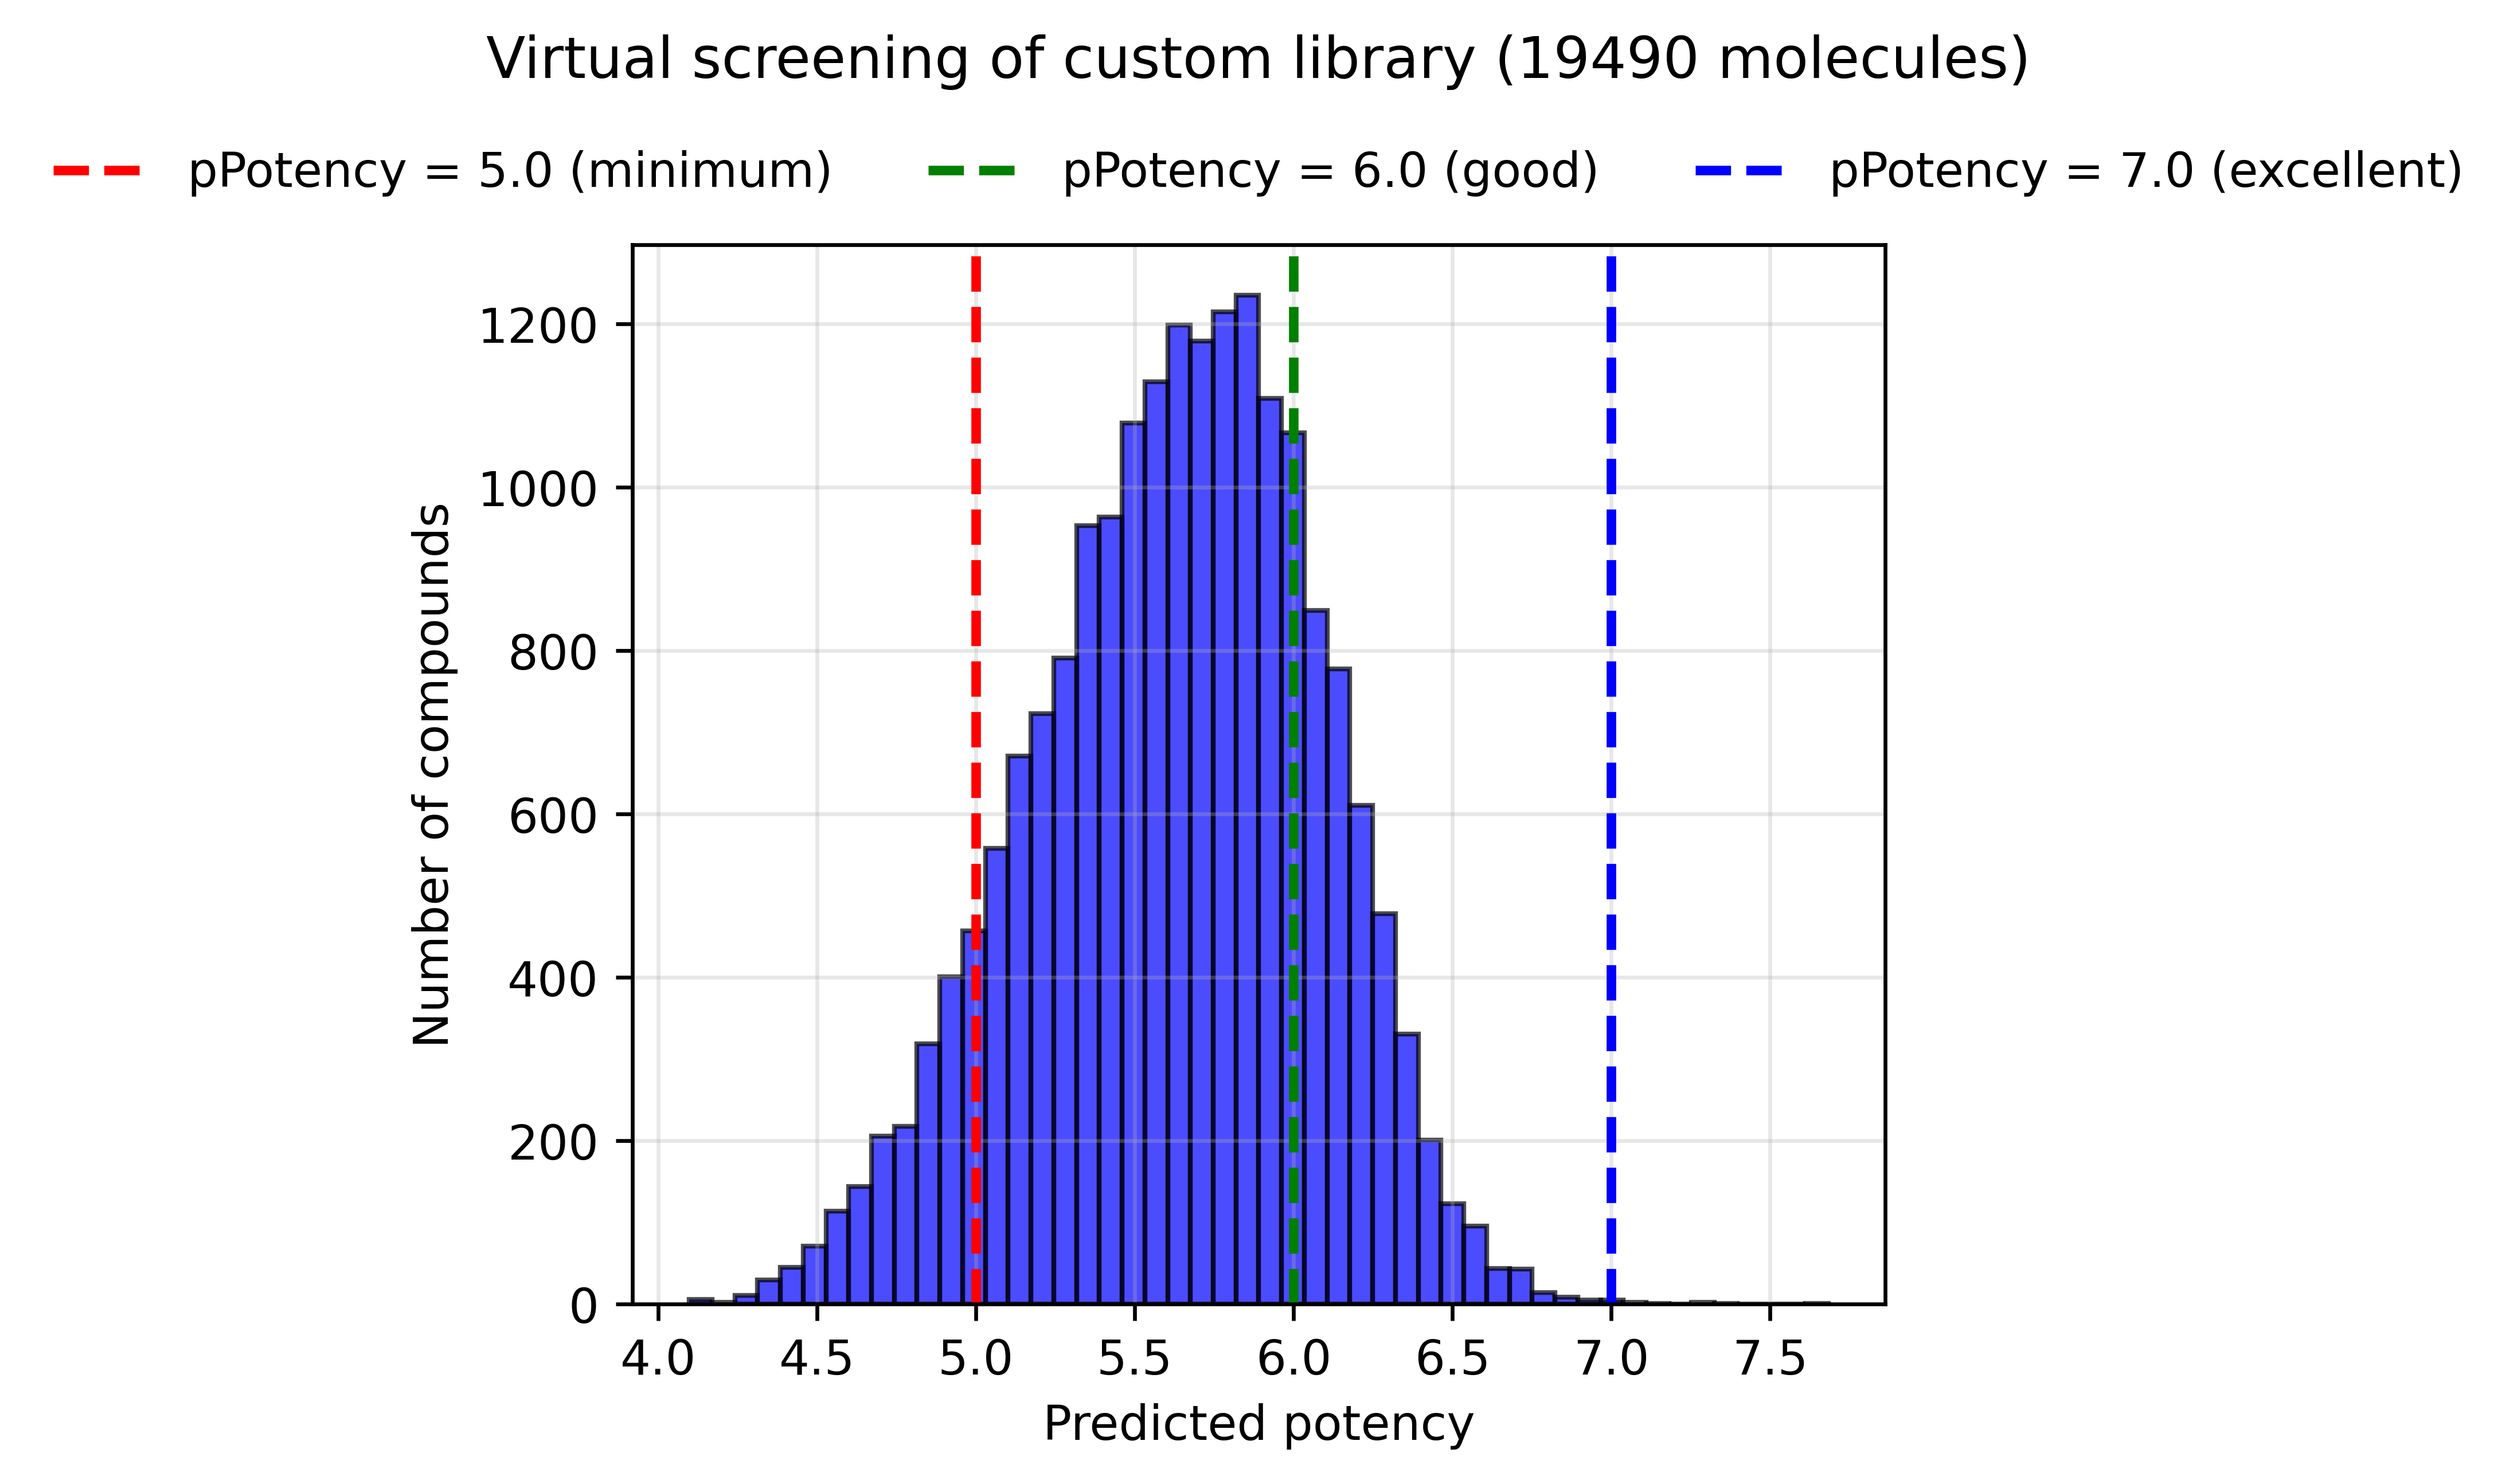

In [88]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y1_lib_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
plt.title(f"Virtual screening of custom library ({len(smi_lib)} molecules)", pad=35)
plt.axvline(x=5, color='r', linestyle='--', linewidth=2, label='pPotency = 5.0 (minimum)') 
plt.axvline(x=6, color='g', linestyle='--', linewidth=2, label='pPotency = 6.0 (good)')
plt.axvline(x=7, color='b', linestyle='--', linewidth=2, label='pPotency = 7.0 (excellent)')

# Legend on top, outside plot area
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(resultsDir + 'virus/allVirus_validation.svg', bbox_inches='tight', dpi=300)
plt.savefig(resultsDir + 'virus/allVirus_validation.png', bbox_inches='tight', dpi=300)
plt.show()

Let us have a look at the compounds:

In [89]:
# Define multiple priority levels
high_priority_idx = np.where(Y1_lib_pred >= 7)[0]
medium_priority_idx = np.where((Y1_lib_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y1_lib_pred >= 5.0) & (Y1_lib_pred < 5))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

High priority (pPotency ≥ 7.0): 9 compounds
Medium priority (6 ≤ pPotency < 7.0): 4096 compounds
Low priority (5 ≤ pPotency < 6): 0 compounds


In [91]:
EnamineAntiviralsData_final = EnamineAntiviralsData.iloc[idx].copy()
EnamineAntiviralsData_final['pPotency_prediction'] = Y1_lib_pred[idx]

EnamineAntiviralsData_final

,Smiles,Source,pPotency_prediction
3819,CC(C)C(NC(=O)c1ccco1)C(=O)N1CC(C)OC(C1)c1ccccc1,Enamine_DDS629,7.025297
7223,C[C@@H](NC(=O)N[C@@H]1C[C@H]1c1ccco1)c1ccc(F)cc1,Enamine_DDS4033,7.126158
15273,Clc1ccccc1OCc1nnc(SCC(=O)NC(=O)NCc2ccco2)o1,Enamine_Phenotypic,7.017346
15478,COc1ccc2n(Cc3ccc(OC)c(OC)c3)c3nc4ccccc4nc3c2c1,Enamine_Phenotypic,7.282813
15488,CCOc1ccc(Cn2c3ccc(OC)cc3c3nc4ccccc4nc23)cc1OC,Enamine_Phenotypic,7.271174
15629,CCOc1ccc(Nc2nc(NCc3ccccc3)c3ccccc3n2)cc1,Enamine_Phenotypic,7.087062
18979,COc1ccccc1Cn1c(nc2ccccc12)C(C)c1ccc(CC(C)C)cc1,Enamine_Phenotypic,7.341850
19039,CC(C)Cc1ccc(cc1)C(C)c1nc2ccccc2n1Cc1ccc(Cl)cc1,Enamine_Phenotypic,7.045982
19059,COc1ccc(Cn2c(nc3ccccc23)C(C)c2ccc(CC(C)C)cc2)cc1,Enamine_Phenotypic,7.683279


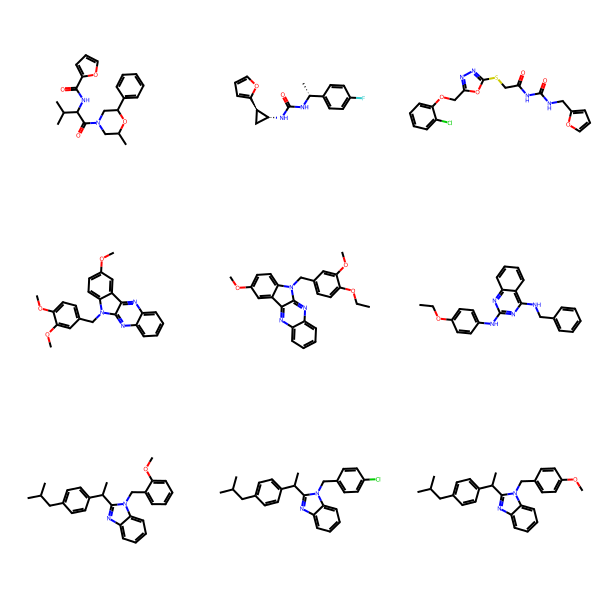

In [92]:
molecules = [Chem.MolFromSmiles(smi) for smi in EnamineAntiviralsData_final.Smiles[:50]]

Draw.MolsToGridImage(molecules, subImgSize=(200,200), molsPerRow=3, useSVG=True)